# Hotspot Overlap And Regime Investigation

This notebook is a second-stage investigation built on top of the by-gene XGBoost analysis.
Its purpose is to answer a practical modeling question: are the worst slices separate problems, or are they mostly the same narrow regime showing up under different labels?

Why this notebook exists:
- If several bad slices overlap heavily, removing all of them would be redundant and potentially too destructive.
- If a bad slice has distinctive sequence or chemistry structure, that is exactly where a CNN may help more than flattened classical features.
- If the model is mostly failing on near-saturated labels, the issue may be target distribution and calibration rather than purely feature representation.

## Investigation Plan

1. Rebuild out-of-fold predictions with the current clean grouped setup.
Why: every downstream slice analysis should be tied to predictions made on held-out genes.

2. Build overlap tables for the main suspicious labels.
Why: `CN112313335A`, `AGT @ {0.1, 10 nM}`, and the narrow `Hep3B` regime may be mostly the same examples.

3. Run within-gene investigations for `AGT`, `APP`, `INHBE`, `PCSK9`, and `MAPT`.
Why: this tells us whether the problem is the gene itself or specific conditions attached to the gene.

4. Compare sequence and chemistry summaries for hotspot slices versus the rest.
Why: if the hard regime has unusual sequence length, base composition, or chemistry composition, a CNN may have a realistic chance to learn something the flat model misses.

5. Inspect saturation and underprediction behavior.
Why: some hotspots have true inhibition near 90 to 100, so the model may be systematically failing in high-response regions.

6. Quantify confounding inside bad patents.
Why: a bad patent result may really be a proxy for one gene, one cell type, or one concentration range.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.merge_historic_data import load_merged_dataset
from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Step 1: Rebuild Held-Out Predictions

Why this step: we want all overlap and hotspot conclusions to come from out-of-fold predictions on unseen genes, not in-sample predictions.

In [2]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

raw_df = load_merged_dataset(cmsirna_path, historic_path)
pipeline = SiRNADataPipeline(target_len=25, fetch_missing_mrna=True)
enriched_df = pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=True,
    add_mrna=True,
)
X, groups, y = pipeline.prepare_for_classical_ml(
    enriched_df,
    target_column="Inhibition",
    use_normalized_conditions=False,
)

mask = ~np.isnan(y)
X = X[mask]
groups = groups[mask]
y = y[mask]
analysis_df = enriched_df.loc[mask].reset_index(drop=True).copy()

analysis_df["patent_group"] = analysis_df.get(
    "patent_ID", pd.Series(index=analysis_df.index, dtype=object)
).fillna("HISTORIC_OR_UNKNOWN")
analysis_df["Authorization_status"] = analysis_df.get(
    "Authorization_status", pd.Series(index=analysis_df.index, dtype=object)
).fillna("UNKNOWN")

analysis_df.shape, len(np.unique(groups))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

((35444, 40), 54)

In [3]:
frozen_params = {
    "n_estimators": 800,
    "max_depth": 4,
    "learning_rate": 0.15881823130907038,
    "subsample": 0.8812898741586134,
    "colsample_bytree": 0.7824379872752019,
    "min_child_weight": 4,
    "reg_lambda": 0.8342807691178866,
    "reg_alpha": 1.4296995092035882,
    "gamma": 0.07531958697602548,
}

gene_cv = GroupKFoldLeakPerGroup(n_splits=3, leak_n=0, random_state=42)
oof_frames = []

for fold_id, (train_idx, test_idx) in enumerate(gene_cv.split(X, y, groups), start=1):
    model = XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42, **frozen_params)
    model.fit(X[train_idx], y[train_idx])
    fold_pred = model.predict(X[test_idx])

    fold_frame = analysis_df.iloc[test_idx].reset_index().rename(columns={"index": "source_index"}).copy()
    fold_frame["row_index"] = test_idx
    fold_frame["fold_id"] = fold_id
    fold_frame["group"] = groups[test_idx]
    fold_frame["y_true"] = y[test_idx]
    fold_frame["y_pred"] = fold_pred
    fold_frame["residual"] = fold_frame["y_true"] - fold_frame["y_pred"]
    fold_frame["abs_error"] = fold_frame["residual"].abs()
    fold_frame["prediction_bias"] = fold_frame["y_pred"] - fold_frame["y_true"]
    oof_frames.append(fold_frame)

predictions_df = pd.concat(oof_frames, ignore_index=True)
predictions_df.head()

,source_index,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,mRNA,Concentration_nM,Time_of_administration_h,mRNA_five_prime,mRNA_three_prime,edit_distance,target_site_pct,Sense_Sequence_One_Hot,Antisense_Sequence_One_Hot,Sense_Acid_One_Hot,Sense_Sugar_One_Hot,Sense_Linker_One_Hot,Antisense_Acid_One_Hot,Antisense_Sugar_One_Hot,Antisense_Linker_One_Hot,Cell_Type_One_Hot,Concentration_log10_nM,Concentration_norm,Time_norm,patent_group,row_index,fold_id,group,y_true,y_pred,residual,abs_error,prediction_bias
0,4680,004-03-02-01275-1n-XXX--1.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00571,TCGGCAGUCCCUUCUGCGUTT,21.0,dTCfgGfcAfgUfcCfcUfuCfuGfcGfudTsdT,1*2'-Deoxy thymidine || 2*2'-Fluorocytidine ||...,ACGCAGAAGGGACUGCCGAT,20.0,1*2'-Fluoroadenosine || 2*2'-O-Methylcytidine ...,-1.2,14.6,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,2.0,0.058778,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4680,1,LPA,-1.2,34.769035,-35.969035,35.969035,35.969035
1,4681,004-03-02-01276-1n-XXX-22.40,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00572,TGUAGCACUCCUGCACCCCTT,21.0,dTGfuAfgCfaCfuCfcUfgCfaCfcCfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,GGGGUGCAGGAGUGCUACAT,20.0,1*2'-Fluoroguanosine || 2*2'-O-Methylguanosine...,22.4,6.2,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.073084,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4681,1,LPA,22.4,0.201030,22.198970,22.198970,-22.198970
2,4682,004-03-02-01277-1n-XXX-29.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00573,TAAUAAGGGGCUGCCACAGTT,21.0,dTAfaUfaAfgGfgGfcUfgCfcAfcAfgdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroadenosine |...,CUGUGGCAGCCCCUUAUUAT,20.0,1*2'-Fluorocytidine || 2*2'-O-Methyluridine ||...,29.2,5.4,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.419219,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 1....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [1.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4682,1,LPA,29.2,47.724365,-18.524365,18.

## Step 2: Overlap Tables For Suspicious Labels

Why this step: if `CN112313335A`, `AGT @ {0.1, 10 nM}`, and a narrow `Hep3B` slice overlap heavily, they are probably one failure mode, not three independent ones.

In [4]:
predictions_df["flag_cn112313335a"] = predictions_df["patent_group"].eq("CN112313335A")
predictions_df["flag_agt_low"] = (
    predictions_df["group"].eq("AGT")
    & predictions_df["Concentration_nM"].isin([0.1, 10.0])
)
predictions_df["flag_hep3b_narrow"] = (
    predictions_df["Cell_Type"].eq("Hep3B")
    & predictions_df["group"].eq("AGT")
    & predictions_df["Concentration_nM"].isin([0.1, 10.0])
)
predictions_df["flag_high_saturation"] = predictions_df["y_true"] >= 90

flag_cols = [
    "flag_cn112313335a",
    "flag_agt_low",
    "flag_hep3b_narrow",
    "flag_high_saturation",
]
predictions_df[flag_cols].sum().to_frame("n_samples")

,n_samples
flag_cn112313335a,366
flag_agt_low,2801
flag_hep3b_narrow,2522
flag_high_saturation,2633


In [5]:
overlap_counts = pd.DataFrame(index=flag_cols, columns=flag_cols, dtype=int)
overlap_jaccard = pd.DataFrame(index=flag_cols, columns=flag_cols, dtype=float)

for left in flag_cols:
    for right in flag_cols:
        left_mask = predictions_df[left]
        right_mask = predictions_df[right]
        intersection = int((left_mask & right_mask).sum())
        union = int((left_mask | right_mask).sum())
        overlap_counts.loc[left, right] = intersection
        overlap_jaccard.loc[left, right] = intersection / union if union else np.nan

print("Overlap counts")
display(overlap_counts)

print("Jaccard overlap")
display(overlap_jaccard.round(3))

Overlap counts


,flag_cn112313335a,flag_agt_low,flag_hep3b_narrow,flag_high_saturation
flag_cn112313335a,366.0,366.0,366.0,318.0
flag_agt_low,366.0,2801.0,2522.0,824.0
flag_hep3b_narrow,366.0,2522.0,2522.0,810.0
flag_high_saturation,318.0,824.0,810.0,2633.0


Jaccard overlap


,flag_cn112313335a,flag_agt_low,flag_hep3b_narrow,flag_high_saturation
flag_cn112313335a,1.000,0.131,0.145,0.119
flag_agt_low,0.131,1.000,0.900,0.179
flag_hep3b_narrow,0.145,0.900,1.000,0.186
flag_high_saturation,0.119,0.179,0.186,1.000


## Step 3: Within-Gene Investigations

Why this step: if a gene is only bad in one concentration or one patent, the issue is condition-specific. If it is bad everywhere, the issue is more gene-wide.

In [6]:
def grouped_spearman(df, group_cols, min_samples=20):
    rows = []
    for keys, group_df in df.groupby(group_cols, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        if pd.isna(corr):
            continue
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: value for col, value in zip(group_cols, keys)}
        row.update({
            "n_samples": len(group_df),
            "spearman": float(corr),
            "mae": float(group_df["abs_error"].mean()),
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
            "mean_bias": float(group_df["prediction_bias"].mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

target_genes = ["AGT", "APP", "INHBE", "PCSK9", "MAPT"]

In [7]:
for gene in target_genes:
    gene_df = predictions_df.loc[predictions_df["group"].eq(gene)].copy()
    print(f"\n=== {gene} overall ===")
    print({
        "n_samples": len(gene_df),
        "spearman": float(spearmanr(gene_df["y_true"], gene_df["y_pred"], nan_policy="omit").statistic),
        "mae": float(gene_df["abs_error"].mean()),
        "mean_true": float(gene_df["y_true"].mean()),
        "mean_pred": float(gene_df["y_pred"].mean()),
        "mean_bias": float(gene_df["prediction_bias"].mean()),
    })

    print(f"\n{gene} by concentration")
    display(grouped_spearman(gene_df, ["Concentration_nM"], min_samples=20).head(15))

    print(f"\n{gene} by cell type")
    display(grouped_spearman(gene_df, ["Cell_Type"], min_samples=20).head(15))

    print(f"\n{gene} by patent")
    display(grouped_spearman(gene_df, ["patent_group"], min_samples=20).head(15))

    print(f"\n{gene} by time")
    display(grouped_spearman(gene_df, ["Time_of_administration_h"], min_samples=20).head(15))


=== AGT overall ===
{'n_samples': 4738, 'spearman': 0.3702935453197165, 'mae': 37.22979420542884, 'mean_true': 57.980388349514556, 'mean_pred': 27.381887435913086, 'mean_bias': -30.598501403772786}

AGT by concentration


,Concentration_nM,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,0.00100,20,-0.485295,13.678399,-0.747500,-7.658817,-6.911318
1,5.00000,26,-0.232176,30.951034,70.858077,41.644997,-29.213082
2,2.22220,20,-0.146250,13.151412,82.997500,72.119720,-10.877774
3,0.20000,75,-0.132094,48.102754,32.660533,-2.009017,-34.669550
4,0.02740,20,-0.084433,27.467578,40.822500,20.521626,-20.300875
5,0.00300,20,-0.030155,13.826906,3.252000,-2.501782,-5.753782
6,10.00000,1477,-0.017217,37.674691,72.446032,42.085175,-30.360862
7,0.50000,28,-0.001916,28.811171,57.732143,29.039759,-28.692386
8,0.74070,20,0.041101,17.244535,81.788500,65.767502,-16.020995
9,0.01000,70,0.046821,38.964685,33.810000,0.630833,-33.179167



AGT by cell type


,Cell_Type,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,HepG2,236,0.152085,20.603331,61.810297,56.023777,-5.786519
1,Hep3B,3936,0.364828,40.670407,59.072111,24.496359,-34.575751
2,Primary human hepatocytes,161,0.560809,23.197939,56.366646,37.601540,-18.765108
3,Huh7,88,0.748732,17.003124,34.960114,37.312500,2.352389
4,HEK293A,219,0.848718,18.016556,48.347032,34.919548,-13.427483
5,Primary Cynomolgus Monkey Hepatocytes,98,0.894275,23.233546,49.760204,31.748627,-18.011577



AGT by patent


...

,Cell_Type,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,Human iPSC-derived cortical neurons,205,0.159453,32.127767,42.600976,65.552010,22.951035
1,Be(2)C cell line,690,0.507915,23.996697,42.984783,24.393934,-18.590849



MAPT by patent


,patent_group,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,WO2023175091A2,213,0.105085,32.686883,43.896714,64.219940,20.323232
1,WO2023049871A2,681,0.493914,24.051860,43.608664,24.890148,-18.718513



MAPT by time


,Time_of_administration_h,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,168.0,205,0.159453,32.127767,42.600976,65.552010,22.951035
1,24.0,690,0.507915,23.996697,42.984783,24.393934,-18.590849


## Step 4: Sequence And Chemistry Profile Comparison

Why this step: if hotspot rows have distinctive sequence composition or chemistry composition, that supports the idea that richer representation learning could help.

In [8]:
profile_df = predictions_df.copy()
profile_df["hotspot_label"] = np.select(
    [
        profile_df["flag_cn112313335a"],
        profile_df["group"].eq("APP") & np.isclose(profile_df["Concentration_nM"], 20.0, equal_nan=False),
        profile_df["group"].eq("INHBE") & np.isclose(profile_df["Concentration_nM"], 100.0, equal_nan=False),
        profile_df["group"].eq("PCSK9") & np.isclose(profile_df["Concentration_nM"], 100.0, equal_nan=False),
        profile_df["group"].eq("MAPT") & (profile_df["Concentration_nM"] > 100),
    ],
    [
        "CN112313335A / AGT low-dose",
        "APP @ 20 nM",
        "INHBE @ 100 nM",
        "PCSK9 @ 100 nM",
        "MAPT > 100 nM",
    ],
    default="Rest",
)

profile_df["antisense_len"] = profile_df["Antisense_seqence"].astype(str).str.len()
profile_df["sense_len"] = profile_df["Sense_seqence"].astype(str).str.len()

for base in ["A", "C", "G", "U", "T"]:
    profile_df[f"antisense_pct_{base}"] = profile_df["Antisense_seqence"].astype(str).str.upper().apply(lambda s: s.count(base) / max(len(s), 1))
    profile_df[f"sense_pct_{base}"] = profile_df["Sense_seqence"].astype(str).str.upper().apply(lambda s: s.count(base) / max(len(s), 1))

for token in ["Fluoro", "Methyl", "phosphorothioate", "Deoxy"]:
    profile_df[f"antisense_has_{token}"] = profile_df["Modification_Types_Antisense_strand"].fillna("").str.contains(token, case=False, regex=False)
    profile_df[f"sense_has_{token}"] = profile_df["Modification_Types_Sense_strand"].fillna("").str.contains(token, case=False, regex=False)

summary_cols = [
    "antisense_len", "sense_len",
    "antisense_pct_A", "antisense_pct_C", "antisense_pct_G", "antisense_pct_U", "antisense_pct_T",
    "sense_pct_A", "sense_pct_C", "sense_pct_G", "sense_pct_U", "sense_pct_T",
    "antisense_has_Fluoro", "antisense_has_Methyl", "antisense_has_phosphorothioate", "antisense_has_Deoxy",
    "sense_has_Fluoro", "sense_has_Methyl", "sense_has_phosphorothioate", "sense_has_Deoxy",
]

feature_profile_summary = profile_df.groupby("hotspot_label")[summary_cols].mean(numeric_only=True).T
feature_profile_summary

hotspot_label,APP @ 20 nM,CN112313335A / AGT low-dose,INHBE @ 100 nM,MAPT > 100 nM,PCSK9 @ 100 nM,Rest
antisense_len,22.970588,23.000000,23.000000,21.265823,21.135593,21.858968
sense_len,20.982353,21.000000,21.000000,20.379747,21.149153,20.456366
antisense_pct_A,0.244315,0.276075,0.328502,0.235310,0.271026,0.282042
antisense_pct_C,0.260718,0.180090,0.185990,0.141202,0.264102,0.213646
antisense_pct_G,0.216612,0.253267,0.271498,0.188270,0.248651,0.222981
antisense_pct_U,0.278098,0.290568,0.180193,0.433436,0.216221,0.268085
antisense_pct_T,0.000256,0.000000,0.033816,0.001781,0.000000,0.013240
sense_pct_A,0.273392,0.293911,0.207937,0.429826,0.219466,0.274480
sense_pct_C,0.220626,0.246552,0.268254,0.197779,0.240605,0.221481
sense_pct_G,0.258745,0.184751,0.183069,0.147430,0.242579,0.212106


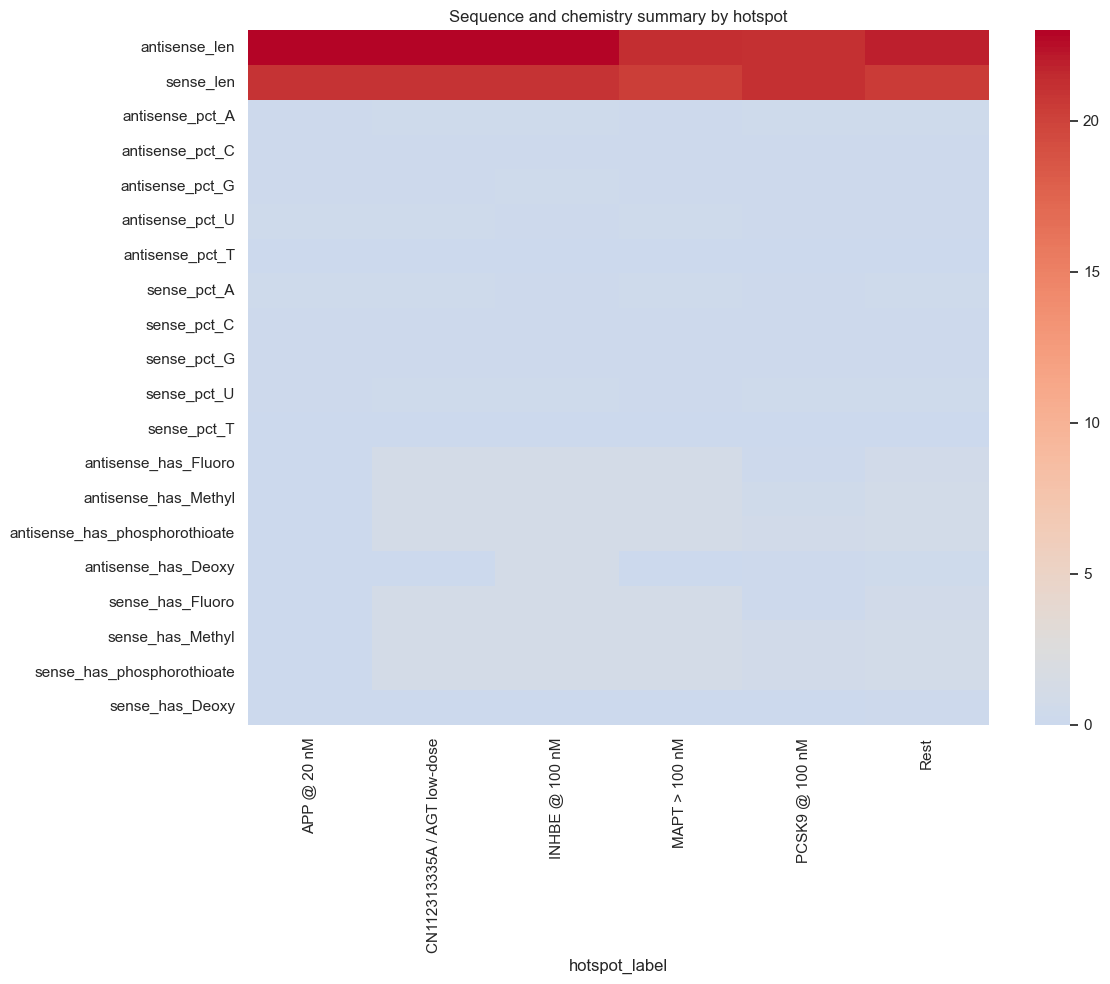

In [9]:
plot_summary = feature_profile_summary.copy()
plt.figure(figsize=(12, 10))
sns.heatmap(plot_summary, cmap="coolwarm", center=plot_summary.mean(axis=1).mean())
plt.title("Sequence and chemistry summary by hotspot")
plt.tight_layout()

## Step 5: Saturation And Underprediction Investigation

Why this step: if the model collapses specifically for very high inhibition values, that points to a target-distribution problem and systematic underprediction.

In [10]:
predictions_df["inhibition_bucket"] = pd.cut(
    predictions_df["y_true"],
    bins=[-np.inf, 0, 25, 50, 75, 90, 100, np.inf],
    labels=["<0", "0-25", "25-50", "50-75", "75-90", "90-100", ">100"],
)

saturation_summary = grouped_spearman(predictions_df, ["inhibition_bucket"], min_samples=20)
saturation_summary

,inhibition_bucket,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,90-100,2541,-0.114657,45.847762,94.860549,49.096039,-45.764509
1,<0,4077,-0.093923,38.965520,-12.494099,25.522942,38.017038
2,75-90,5181,-0.007656,31.789725,82.584457,51.894157,-30.690303
3,50-75,8373,0.065155,20.263155,62.866567,49.869183,-12.997387
4,25-50,7584,0.132121,19.558080,37.821712,41.616440,3.794729
5,0-25,7688,0.168133,23.959358,12.281720,29.439907,17.158187


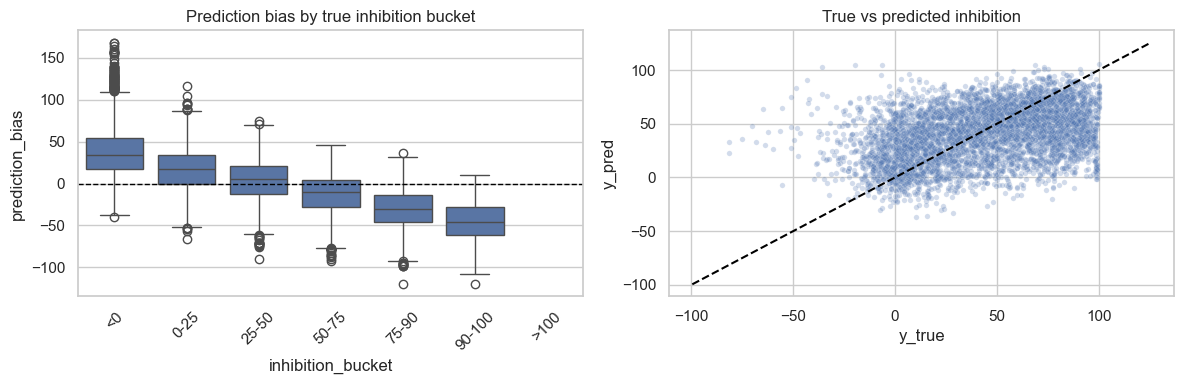

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=predictions_df, x="inhibition_bucket", y="prediction_bias", ax=axes[0])
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Prediction bias by true inhibition bucket")
axes[0].tick_params(axis="x", rotation=45)

sns.scatterplot(data=predictions_df.sample(min(len(predictions_df), 5000), random_state=42), x="y_true", y="y_pred", alpha=0.25, s=15, ax=axes[1])
lims = [min(predictions_df["y_true"].min(), predictions_df["y_pred"].min()), max(predictions_df["y_true"].max(), predictions_df["y_pred"].max())]
axes[1].plot(lims, lims, linestyle="--", color="black")
axes[1].set_title("True vs predicted inhibition")
plt.tight_layout()

## Step 6: Patent Confounding Tables

Why this step: if a bad patent is dominated by one gene, one concentration, one cell type, or one timepoint, it should be interpreted as a narrow regime rather than a broad patent-level defect.

In [12]:
bad_patents = grouped_spearman(predictions_df, ["patent_group"], min_samples=50)
bad_patents.head(15)

,patent_group,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,CN112313335A,366,-0.809342,73.222705,95.782978,22.560272,-73.222705
1,US20220380773A1,170,-0.538620,39.857762,41.005882,61.545261,20.539379
2,CN117210468A,225,-0.027255,21.581029,25.280444,21.043114,-4.237332
3,WO2023064530A1,135,-0.021430,30.574649,50.096000,70.296783,20.200776
4,WO2023091644A2,1445,0.005219,26.344493,48.121391,60.233562,12.112173
5,TW202321444A,190,0.009029,25.529923,22.762105,46.668053,23.905937
6,CN101484588B,718,0.024178,28.975280,49.736769,51.232025,1.495259
7,CN116801886A,272,0.034969,35.375873,50.522426,38.116009,-12.406416
8,WO2022121959A1,100,0.040914,38.676509,64.982500,48.505009,-16.477490
9,CN113980966A,57,0.047696,55.286325,83.438596,28.212877,-55.225717


In [13]:
def top_share_table(df, column, top_n=10):
    counts = df[column].fillna("MISSING").value_counts().head(top_n)
    out = counts.rename_axis(column).reset_index(name="n_samples")
    out["pct_within_slice"] = out["n_samples"] / len(df)
    return out

selected_patents = bad_patents.head(5)["patent_group"].tolist()

for patent in selected_patents:
    patent_df = predictions_df.loc[predictions_df["patent_group"].eq(patent)].copy()
    print(f"\n=== {patent} ===")
    print({
        "n_samples": len(patent_df),
        "spearman": float(spearmanr(patent_df["y_true"], patent_df["y_pred"], nan_policy="omit").statistic),
        "mae": float(patent_df["abs_error"].mean()),
        "mean_true": float(patent_df["y_true"].mean()),
        "mean_pred": float(patent_df["y_pred"].mean()),
        "mean_bias": float(patent_df["prediction_bias"].mean()),
    })
    print("Top genes")
    display(top_share_table(patent_df, "group", top_n=10))
    print("Top concentrations")
    display(top_share_table(patent_df, "Concentration_nM", top_n=10))
    print("Top cell types")
    display(top_share_table(patent_df, "Cell_Type", top_n=10))
    print("Top times")
    display(top_share_table(patent_df, "Time_of_administration_h", top_n=10))


=== CN112313335A ===
{'n_samples': 366, 'spearman': -0.8093423089613648, 'mae': 73.22270518229796, 'mean_true': 95.78297814207649, 'mean_pred': 22.560272216796875, 'mean_bias': -73.22270518229796}
Top genes


,group,n_samples,pct_within_slice
0,AGT,366,1.0


Top concentrations


,Concentration_nM,n_samples,pct_within_slice
0,0.1,184,0.502732
1,10.0,182,0.497268


Top cell types


...

,Concentration_nM,n_samples,pct_within_slice
0,1.0,412,0.285121
1,0.3,147,0.101730
2,0.1,147,0.101730
3,30.0,132,0.091349
4,50.0,131,0.090657
5,100.0,123,0.085121
6,10.0,117,0.080969
7,150.0,88,0.060900
8,5.0,43,0.029758
9,15.0,35,0.024221


Top cell types


,Cell_Type,n_samples,pct_within_slice
0,Primary human hepatocytes,1445,1.0


Top times


,Time_of_administration_h,n_samples,pct_within_slice
0,48.0,1445,1.0


## How To Use This Notebook

Interpretation guide:
- If overlap is near-complete, several hotspot labels are really the same regime.
- If a gene is only bad under one condition, prefer a narrow ablation over removing the whole gene or patent.
- If hotspot sequence/chemistry summaries differ from the rest, that is a reason to test whether a CNN helps.
- If high true inhibition buckets show large negative bias, the problem is partly saturation and calibration.
- If a bad patent is dominated by one gene and one concentration, treat it as a confounded regime rather than a patent-wide rule.

# Conclusions:

- The main hotspots are mostly narrow regimes, not broad data-quality failures. CN112313335A is entirely AGT + Hep3B + 24h + {0.1, 10 nM} with extreme underprediction: Spearman -0.81, bias -73.2
- AGT low-dose and the narrow Hep3B regime overlap heavily with each other, but not completely with CN112313335A. Jaccard is 0.90 between flag_agt_low and flag_hep3b_narrow, while CN112313335A is only a subset of that broader problem. So the real failure mode is larger than one patent.
- Saturation is a major issue. The 90-100 inhibition bucket has n=2541, Spearman -0.115, and mean bias -45.8. The model is systematically pulling very strong true responses downward. This is not just one patent problem.
- Several “bad patents” are actually single-regime proxies:US20220380773A1 = only APP @ 20 nM @ Hela @ 24h
WO2023064530A1 = only PLN @ 10 nM @ Hepa1-6 @ 24h
WO2023091644A2 = only HSD17B13 @ primary human hepatocytes @ 48h
CN117210468A = only PCSK9 with a narrow condition mix
- The within-gene results show condition-specific failures, not blanket gene failures:AGT is broadly biased downward, especially Hep3B and some low/high-response concentrations.
APP is mostly okay except 20 nM / Hela, where Spearman flips negative.
INHBE is mainly bad at 100 nM and in primary hepatocyte contexts.
PCSK9 is not catastrophically bad overall; 100 nM is weak, but not enough to remove the whole gene or bucket.
MAPT is mainly problematic at 40 and 200 nM, with strong overprediction there.
-The feature-profile table suggests some hotspots are chemically distinct. CN112313335A / AGT low-dose and INHBE @ 100 nM are fully fluoro/methyl/phosphorothioate-like, while APP @ 20 nM looks very different. That supports trying a CNN rather than only deleting rows.